First we will import everything we need to test the Multilayer Perceptron


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from ml_from_scratch.supervised.multilayer_perceptron import NeuralNet

Now we have to load the dataset that we actually want to test our model on

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Note we are dividing here to scale to values in between 0 and 1

X = mnist.data / 255.0                 
y = mnist.target.astype(int)

# We are only using the first 10000 values so training time isnt too absurd

X = X[:10000]
y = y[:10000]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Now that we have our large subset of the training data scaled to the level we would like, I will graph a couple digits just to give a picture of what the training data actually looks like

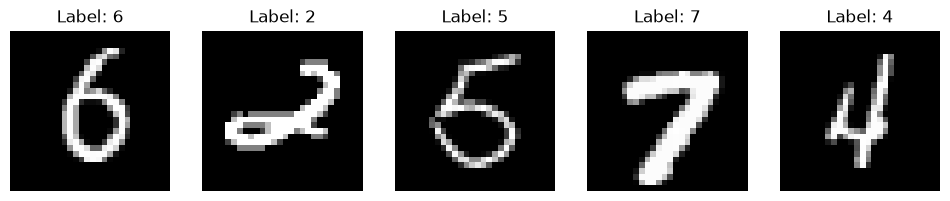

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

As described earlier, the whiter squares are given higher values and the darker ones lower values so that is how we are quantitatively training our model. Some things to note considering how that works, that 5 has very little black space preventing it from being a 6 so the model may struggle to classify that one. We will check later what it thinks it is once the model has been trained. Now we must create an instance of our model and train it.

In [6]:
Y_train = np.zeros((len(y_train), 10))
Y_train[np.arange(len(y_train)), y_train] = 1

net = NeuralNet(random_state=0)
net.train(X_train, Y_train, alpha=2.0, epochs=1000)   

Now that the model is trained, let us graph the cost curve to vizualize the models improvement over time

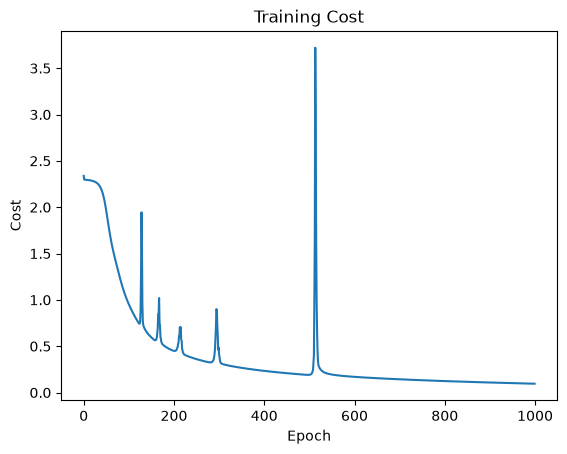

In [7]:
plt.plot(net.costs)
plt.xlabel('Epoch'); plt.ylabel('Cost'); plt.title('Training Cost')
plt.show()

This is interesting because the cost curve seems to jump a couple times. There can be a few reasons this happens. I chose a fairly high alpha which could have caused it to jump way far out on accident, it also could be because our model is utilizing stochastic gradient descent. This means a specific batch of data could push it really far in a weird direction and then it will even back out. This happens because we are training on small subsets of the data sequentially rather than the entire dataset every time. Now lets check the accuracy of the model on the testing set

In [8]:
train_acc = np.mean(net.predict(X_train) == y_train)
test_acc = np.mean(net.predict(X_test) == y_test)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Train accuracy: 0.9806
Test accuracy:  0.9280


93% is not bad, especially considering if you remember how mishapen some of these numbers really are. Now lets test to see if we were correct in guessing that the model would struggle to predict that 5 that was shown previously.

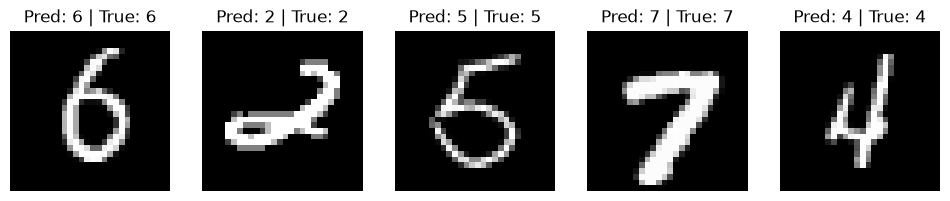

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
preds = net.predict(X_train[:5])
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {preds[i]} | True: {y_train[i]}")
    ax.axis('off')
plt.show()

Never mind! The model seems to have figured it out. Note that this is more likely as this data was trained on so it is easier for the model to predict. Now, I will produce one more interesting visual which is a heatmap of the weight matrices in the first layer. This shows what the model is considering to push to the next layer.

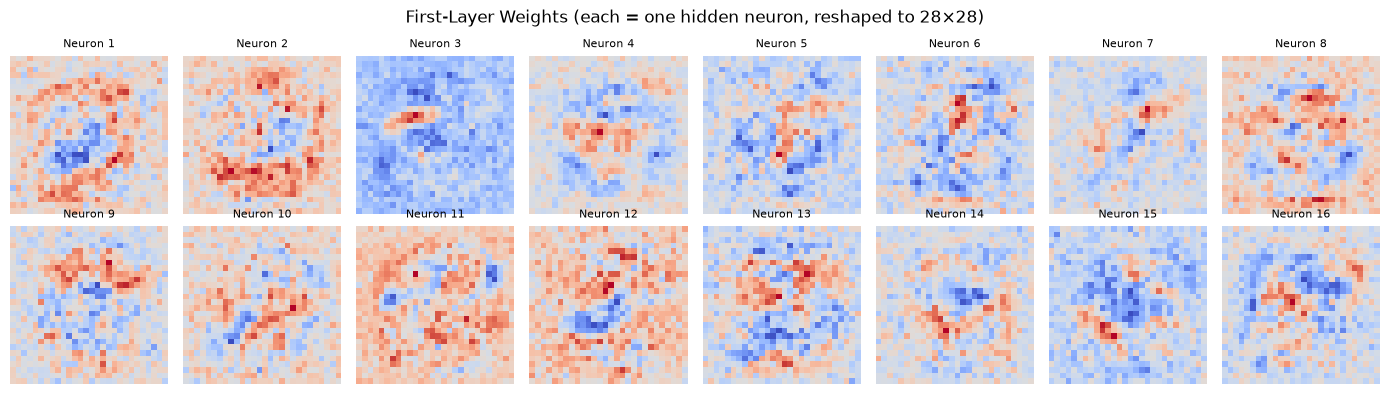

In [15]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    # W1 is (784, 16): column i is the weights for hidden neuron i
    neuron_weights = net.W1[:, i].reshape(28, 28)
    ax.imshow(neuron_weights, cmap='coolwarm')
    ax.set_title(f"Neuron {i+1}", fontsize=8)
    ax.axis('off')
plt.suptitle('First-Layer Weights (each = one hidden neuron, reshaped to 28×28)')
plt.tight_layout()
plt.show()

I think this is just a cool visualisation to see what each neuron is actually doing. Especially looking at neuron 3, it seems to have found a shape that it is looking for which could maybe be used to classify sixes and eights as well as some others possibly. From this, we have shown and tested the multilayer perceptron on the MNIST dataset.